# Simplify example observation with the agent

In [13]:
# Helper: List available checkpoints in a run directory
# Uncomment and run this to see what checkpoints are available:
# import os
# run_dir = Path("../train_rl_agent/runs/para/20251111-163752/saved_agent")
# if run_dir.exists():
#     checkpoints = sorted([int(f.name.replace("paras", "").replace(".json", "")) 
#                          for f in run_dir.glob("paras*.json")])
#     print(f"Available checkpoints: {checkpoints}")
#     print(f"Latest checkpoint: {max(checkpoints) if checkpoints else 'None'}")
# else:
#     print(f"Directory not found: {run_dir}")


In [1]:
import sys
sys.path.append("../../")


from pathlib import Path

import keras
import numpy as np
import tensorflow as tf
import tensorflow_gnn as tfgnn
import tensorflow_gnn.proto.graph_schema_pb2 as schema_pb2
from google.protobuf import text_format

from zxreinforce.ZX_env import  ZXCalculus
from zxreinforce.rl_schemas import OBSERVATION_SCHEMA_ZX_final
from zxreinforce.Resetters import Resetter_ZERO_PI_PIHALF_ARB_hada, Resetter_FlowPatterns, Resetter_BrickworkPattern
from zxreinforce.PPO_Agent_mult_GPU import PPOAgentPara
from zxreinforce.RL_Models import build_gnn_actor_model, build_gnn_critic_model
from zxreinforce.batch_utils import batch_mask_combined, batch_obs_combined_traj
from zxreinforce.plot_utils import plot_action

2025-12-11 13:27:12.930785: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-11 13:27:12.932849: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-11 13:27:12.982013: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-11 13:27:12.983573: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 13:27:13.693440: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
# Load agent
graph_schema = text_format.Merge(OBSERVATION_SCHEMA_ZX_final, schema_pb2.GraphSchema())
graph_tensor_spec = tfgnn.create_graph_spec_from_schema_pb(graph_schema)

# Use default strategy (works with CPU or GPU)
strategy = tf.distribute.get_strategy()

with strategy.scope():
    actor_model = build_gnn_actor_model(graph_tensor_spec=graph_tensor_spec)
    critic_model = build_gnn_critic_model(graph_tensor_spec=graph_tensor_spec)
    optimizer = keras.optimizers.Adam()

# Path to your trained model
# Update this to point to your training run directory
# Most recent run: 20251111-163752 (has checkpoints up to 2500)
# load_path_agent = Path("../train_rl_agent/runs/para/20251209-181934/saved_agent")
load_path_agent = Path("../train_rl_agent/runs/para/20251209-212049/saved_agent")
load_idx = 1000  # Use the final checkpoint, or change to any checkpoint (10, 100, 500, 1000, etc.)

print(f"Loading model from: {load_path_agent}")
print(f"Checkpoint index: {load_idx}")

ppo_agent = PPOAgentPara.load_from_folder(load_path_agent, actor_model, critic_model, optimizer, strategy, load_idx)
print("Model loaded successfully!")

2025-12-11 13:27:15.823888: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-12-11 13:27:15.973926: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: annotated name 'piece_name' can't be nonlocal (__autograph_generated_file112z4ncj.py, line 18)
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: annotated name 'piece_name' can't be nonlocal (__autograph_generated_file112z4ncj.py, line 18)
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-12-11 13:27:16.659996: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder_1' with dtype int32 and shape [1]
	 [[{{node Placeholder_1}}]]
2025-12-11 13:27:16.660124: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder_1' with dtype int32 and shape [1]
	 [[{{node Placeholder_1}}]]
2025-12-11 13:27:16.719038: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder_3' with dtype int32 and shape [1]
	 [[{{node Plac

Loading model from: ../train_rl_agent/runs/para/20251209-212049/saved_agent
Checkpoint index: 1000
Model loaded successfully!


In [3]:
# Build env 
max_steps = 200
add_reward_per_step = 0
seed=249
count_down_from=20
dont_allow_stop=False


# Params for initial env observations
n_in_min=1
n_in_max=3
pi_fac=0.4
pi_half_fac=0.4
arb_fac=0.4
p_hada=0.2
min_mean_neighbours=2
max_mean_neighbours=4
fac = 1
min_spiders=10 * fac
max_spiders=15 * fac

# Resetter for inital observation
resetter = Resetter_BrickworkPattern(
                                    n_qubits_min=2,
                                    n_qubits_max=4,
                                    depth_min=2,
                                    depth_max=4,
                                    # n_in_min=n_in_min,
                                    # n_in_max=n_in_max,
                                    #  n_out_min=2,
                                    # n_out_max=4,
                                    # n_layers_min=2,
                                    # n_layers_max=4,
                                    # nodes_per_layer_min=3,
                                    # nodes_per_layer_max=6,
                                    # p_edge=0.5,
                                    # pi_fac=0.5,
                                    # pi_half_fac=0.5,
                                    # arb_fac=0.5,
                                    # p_hada=0.1,
                                    rng=np.random.default_rng(seed))


env = ZXCalculus(max_steps=max_steps, 
            add_reward_per_step=add_reward_per_step,
            resetter=resetter,
            check_consistencty=False,
            count_down_from=count_down_from,
            dont_allow_stop=dont_allow_stop)

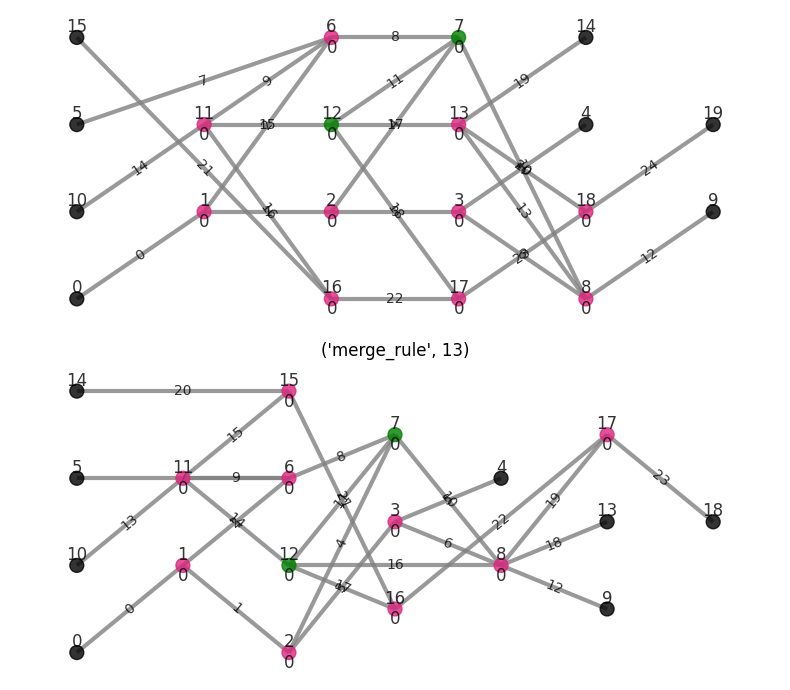

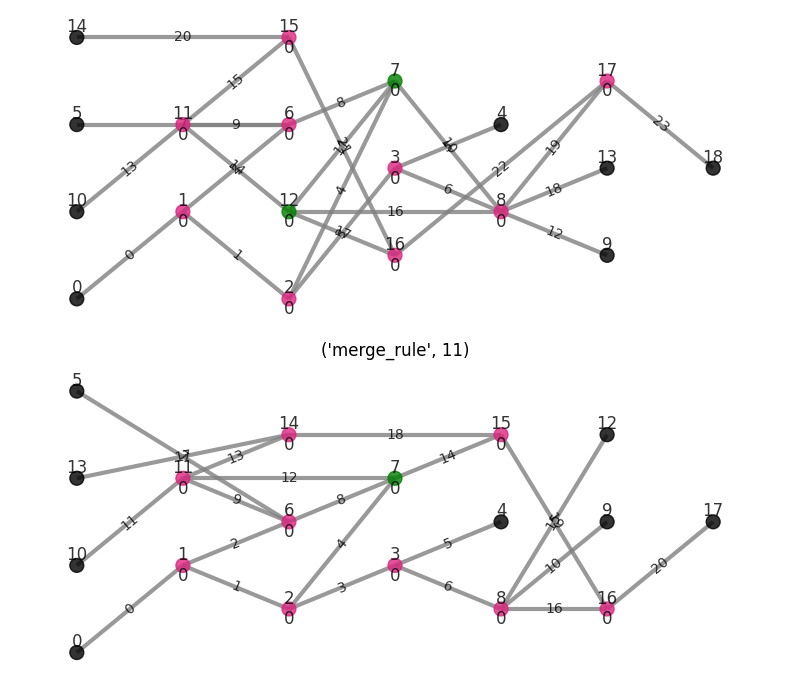

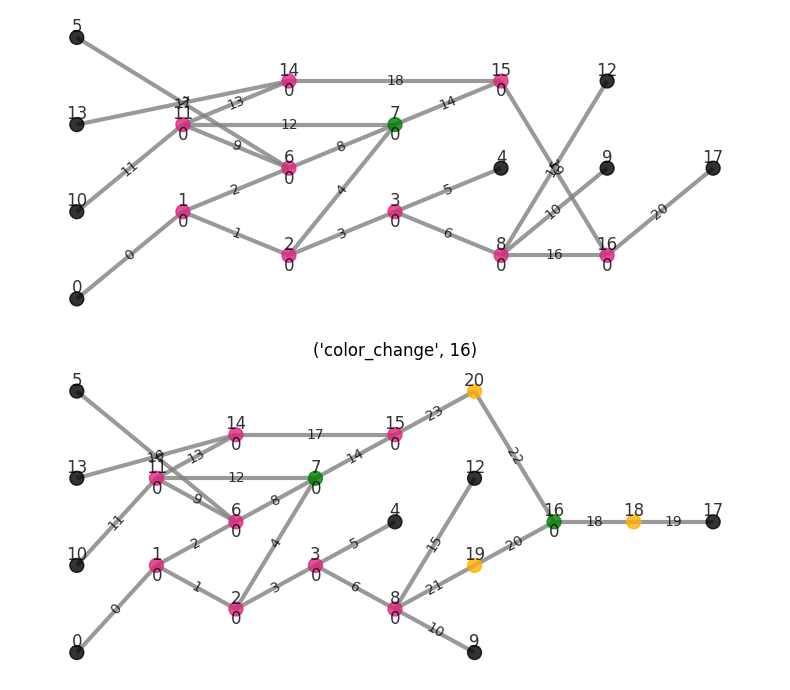

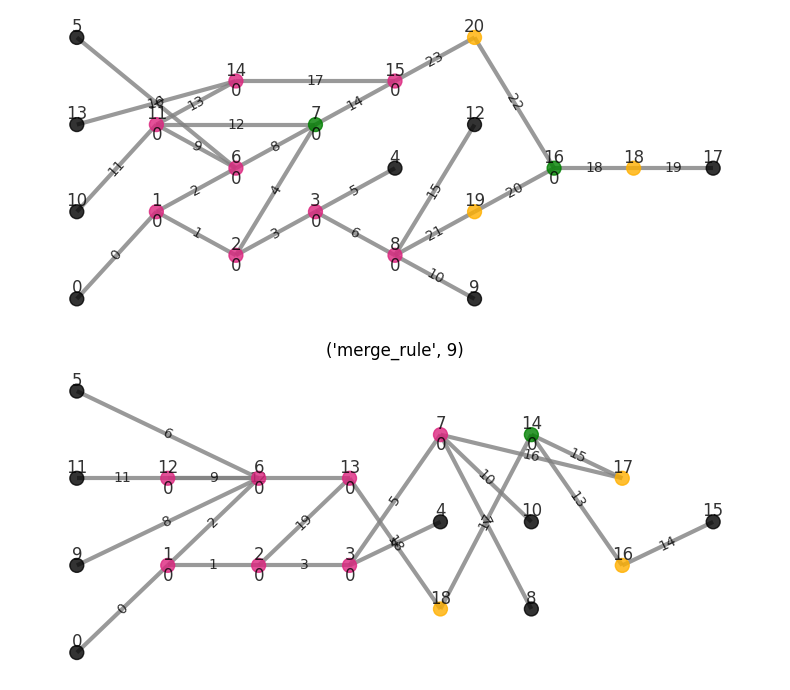

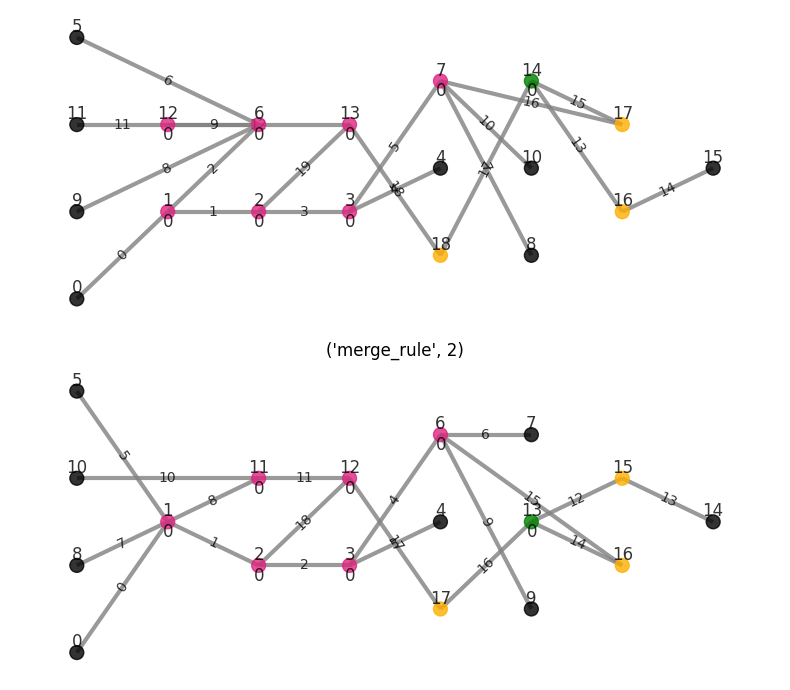

In [4]:
# Optimize for n_steps
n_steps = 5

observation, mask = env.reset()
observation = [observation]
mask = [mask]

for step in range(0, n_steps):

    # Batch graph observation to graph tensor and mask to tensor
    observation_batched = batch_obs_combined_traj(observation)
    mask_batched = batch_mask_combined(mask)
    # Get the logprobs, action
    action, logprobability_t  = ppo_agent.sample_action_logits_trajectory(observation_batched, mask_batched)
    # Take one step in the environment
    next_observation, next_mask, reward, next_done = env.step(action.numpy()[0])
    
    # Plot action
    plot_action(observation[0], next_observation, action.numpy()[0])
    
    observation = [next_observation]
    mask = [next_mask]
